C:\Users\tomer\AppData\Local\Temp\ipykernel_34368\113923236.py:6: DtypeWarning: Columns (0: snr_db, 1: source_id) have mixed types. Specify dtype option on import or set low_memory=False.
  meta = pd.read_csv('../data/metadata.csv')


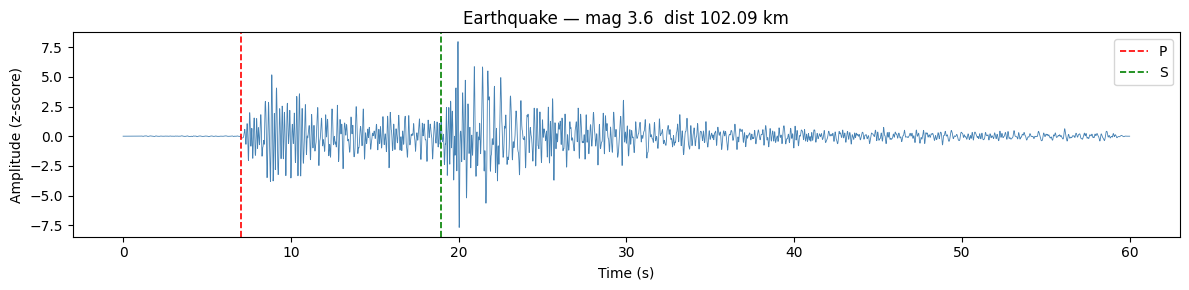

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

X    = np.load('../data/waveforms.npy')
meta = pd.read_csv('../data/metadata.csv')

# Pick the first earthquake
idx      = np.where(meta['label'].values == 1)[0][0]
waveform = X[idx]
row      = meta.iloc[idx]

time = np.arange(len(waveform)) / 100.0   # seconds (100 Hz sample rate)

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(time, waveform, lw=0.6, color='steelblue')

# Mark P and S arrivals if available
for col, label, color in [('p_arrival_sample', 'P', 'red'), ('s_arrival_sample', 'S', 'green')]:
    if col in row and pd.notna(row[col]):
        ax.axvline(row[col] / 100.0, color=color, lw=1.2, linestyle='--', label=label)

ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude (z-score)')
ax.set_title(f"Earthquake — mag {row.get('source_magnitude', '?')}  dist {row.get('source_distance_km', '?')} km")
ax.legend()
plt.tight_layout()
plt.show()

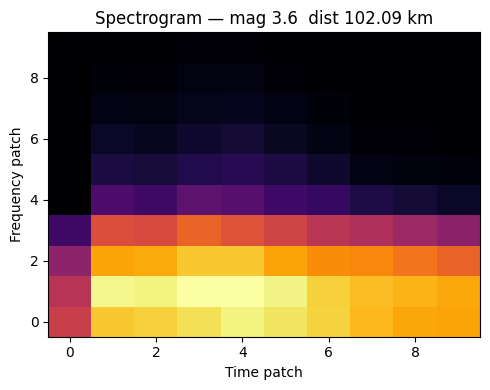

In [2]:
X_spec = np.load('../data/spectrograms/spectrograms_10x10.npy')

fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(X_spec[idx], origin='lower', aspect='auto', cmap='inferno')
ax.set_xlabel('Time patch')
ax.set_ylabel('Frequency patch')
ax.set_title(f"Spectrogram — mag {row.get('source_magnitude', '?')}  dist {row.get('source_distance_km', '?')} km")
plt.tight_layout()
plt.show()

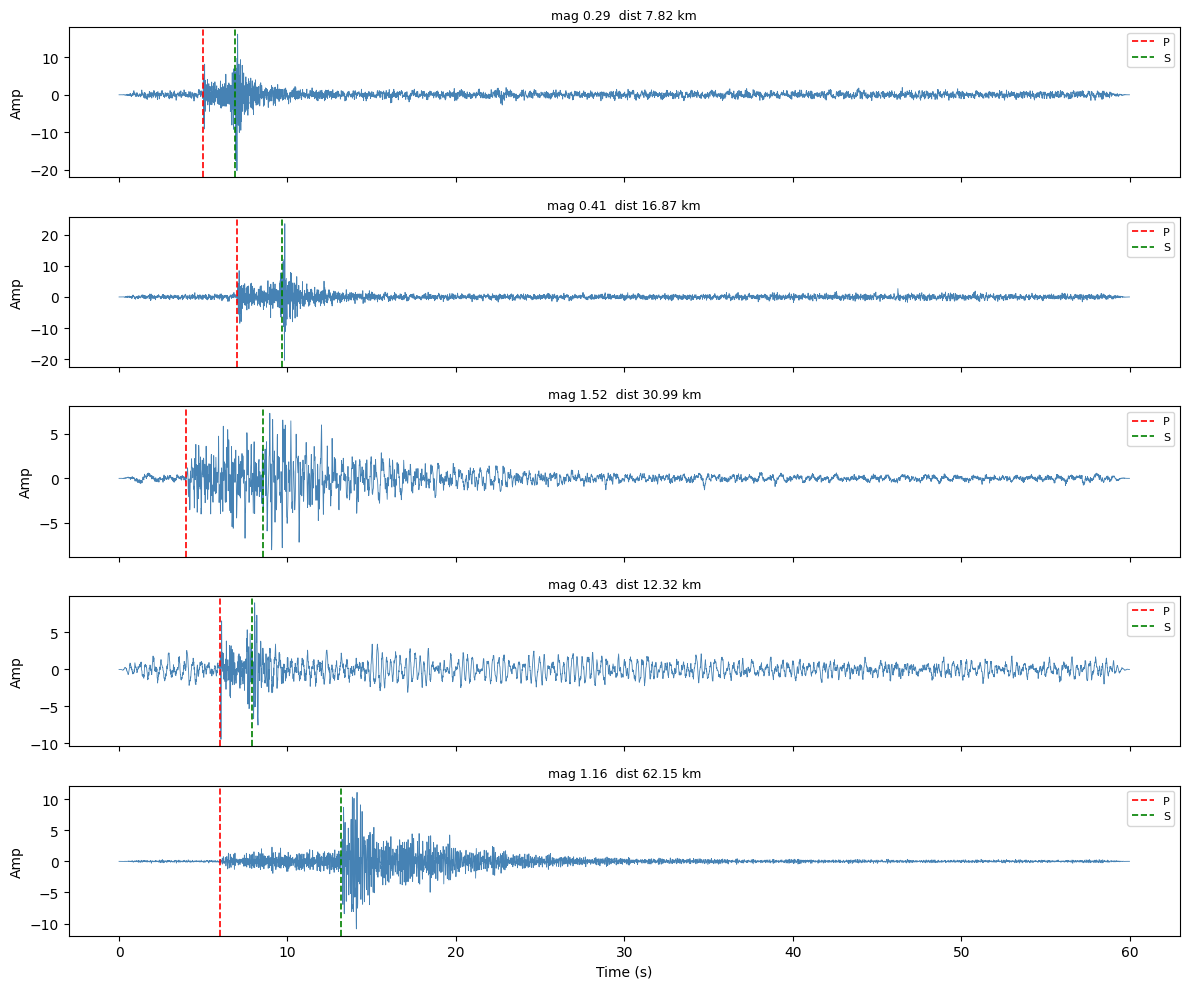

In [3]:
rng     = np.random.default_rng(0)
eq_idxs = np.where(meta['label'].values == 1)[0]
sample  = rng.choice(eq_idxs, size=5, replace=False)

fig, axes = plt.subplots(5, 1, figsize=(12, 10), sharex=True)
for ax, idx in zip(axes, sample):
    waveform = X[idx]
    row      = meta.iloc[idx]
    time     = np.arange(len(waveform)) / 100.0
    ax.plot(time, waveform, lw=0.6, color='steelblue')
    for col, label, color in [('p_arrival_sample', 'P', 'red'), ('s_arrival_sample', 'S', 'green')]:
        if col in row and pd.notna(row[col]):
            ax.axvline(row[col] / 100.0, color=color, lw=1.2, linestyle='--', label=label)
    ax.set_title(f"mag {row.get('source_magnitude', '?')}  dist {row.get('source_distance_km', '?')} km", fontsize=9)
    ax.set_ylabel('Amp')
    ax.legend(fontsize=8)

axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

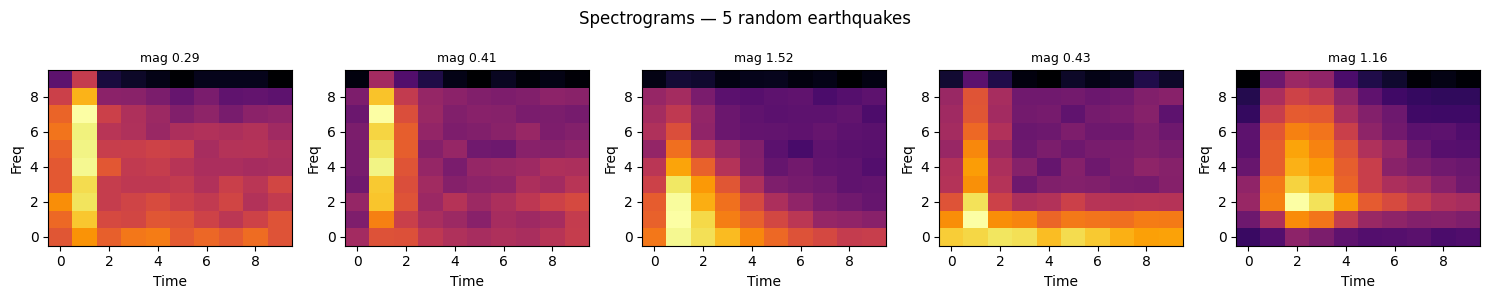

In [4]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for ax, idx in zip(axes, sample):
    ax.imshow(X_spec[idx], origin='lower', aspect='auto', cmap='inferno')
    row = meta.iloc[idx]
    ax.set_title(f"mag {row.get('source_magnitude', '?')}", fontsize=9)
    ax.set_xlabel('Time')
    ax.set_ylabel('Freq')
plt.suptitle('Spectrograms — 5 random earthquakes')
plt.tight_layout()
plt.show()

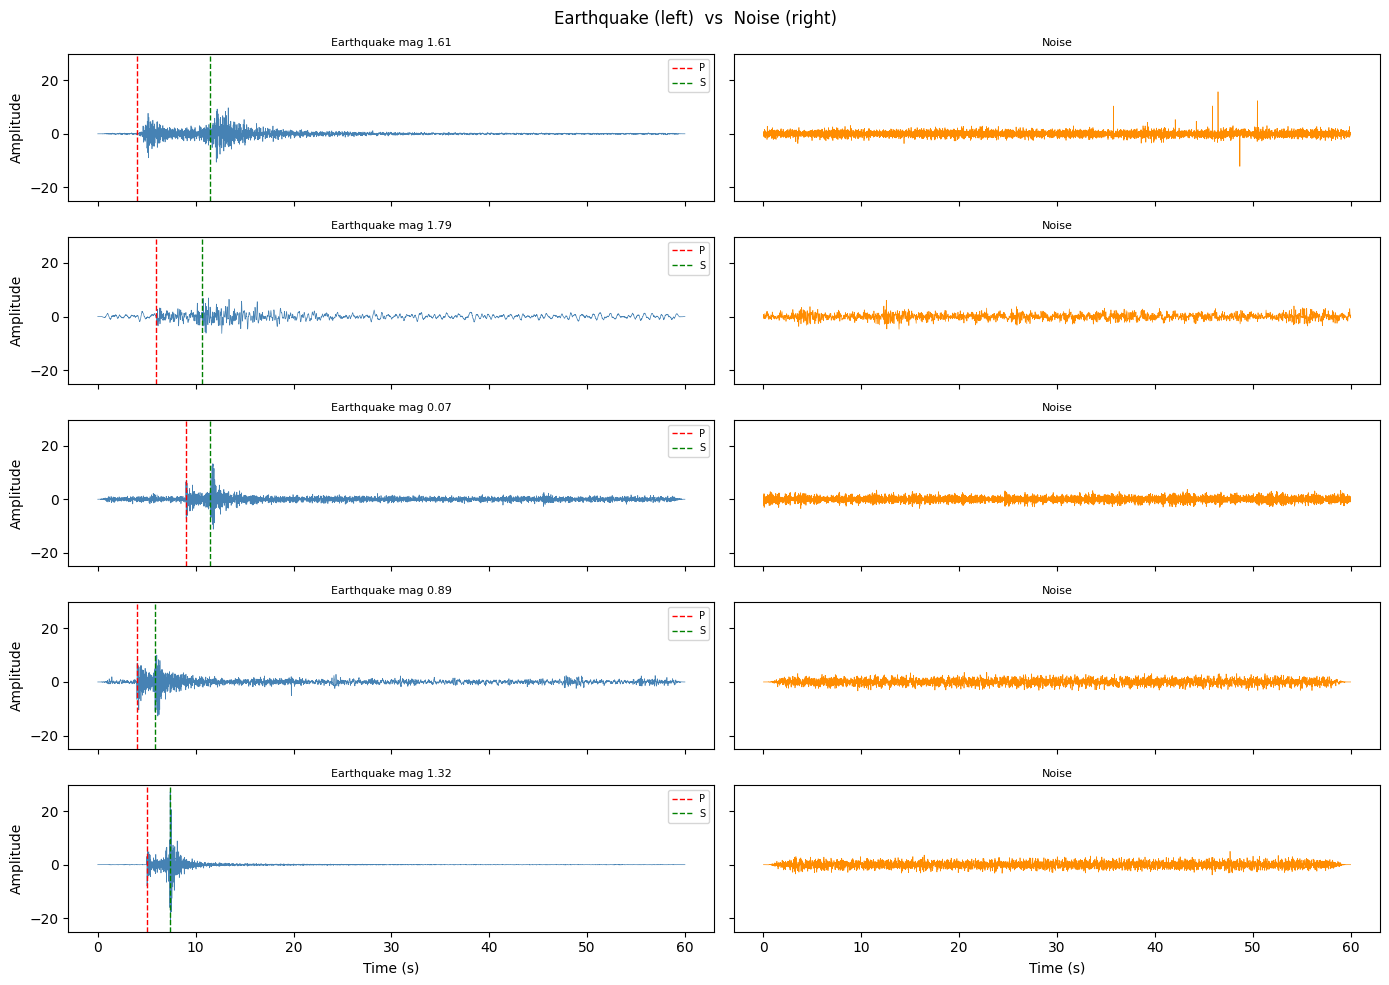

In [5]:
# 5 random earthquakes (left) vs 5 random noise traces (right)
rng        = np.random.default_rng(1)
eq_idxs    = np.where(meta['label'].values == 1)[0]
noise_idxs = np.where(meta['label'].values == 0)[0]
eq_sample    = rng.choice(eq_idxs,    size=5, replace=False)
noise_sample = rng.choice(noise_idxs, size=5, replace=False)

fig, axes = plt.subplots(5, 2, figsize=(14, 10), sharex=True, sharey=True)
fig.suptitle('Earthquake (left)  vs  Noise (right)', fontsize=12)

for row_i, (eq_i, noi_i) in enumerate(zip(eq_sample, noise_sample)):
    for col_i, (trace_idx, color, label) in enumerate([
        (eq_i,  'steelblue', 'Earthquake'),
        (noi_i, 'darkorange', 'Noise'),
    ]):
        ax  = axes[row_i, col_i]
        row = meta.iloc[trace_idx]
        w   = X[trace_idx]
        t   = np.arange(len(w)) / 100.0
        ax.plot(t, w, lw=0.5, color=color)
        if col_i == 0:
            for col_name, arr_label, arr_color in [('p_arrival_sample', 'P', 'red'), ('s_arrival_sample', 'S', 'green')]:
                if col_name in row and pd.notna(row[col_name]):
                    ax.axvline(row[col_name] / 100.0, color=arr_color, lw=1, linestyle='--', label=arr_label)
            ax.legend(fontsize=7)
        mag  = row.get('source_magnitude', '')
        dist = row.get('source_distance_km', '')
        title = f"{label}"
        if pd.notna(mag) and mag != '':
            title += f" mag {mag}"
        ax.set_title(title, fontsize=8)

for ax in axes[-1]:
    ax.set_xlabel('Time (s)')
for ax in axes[:, 0]:
    ax.set_ylabel('Amplitude')

plt.tight_layout()
plt.show()

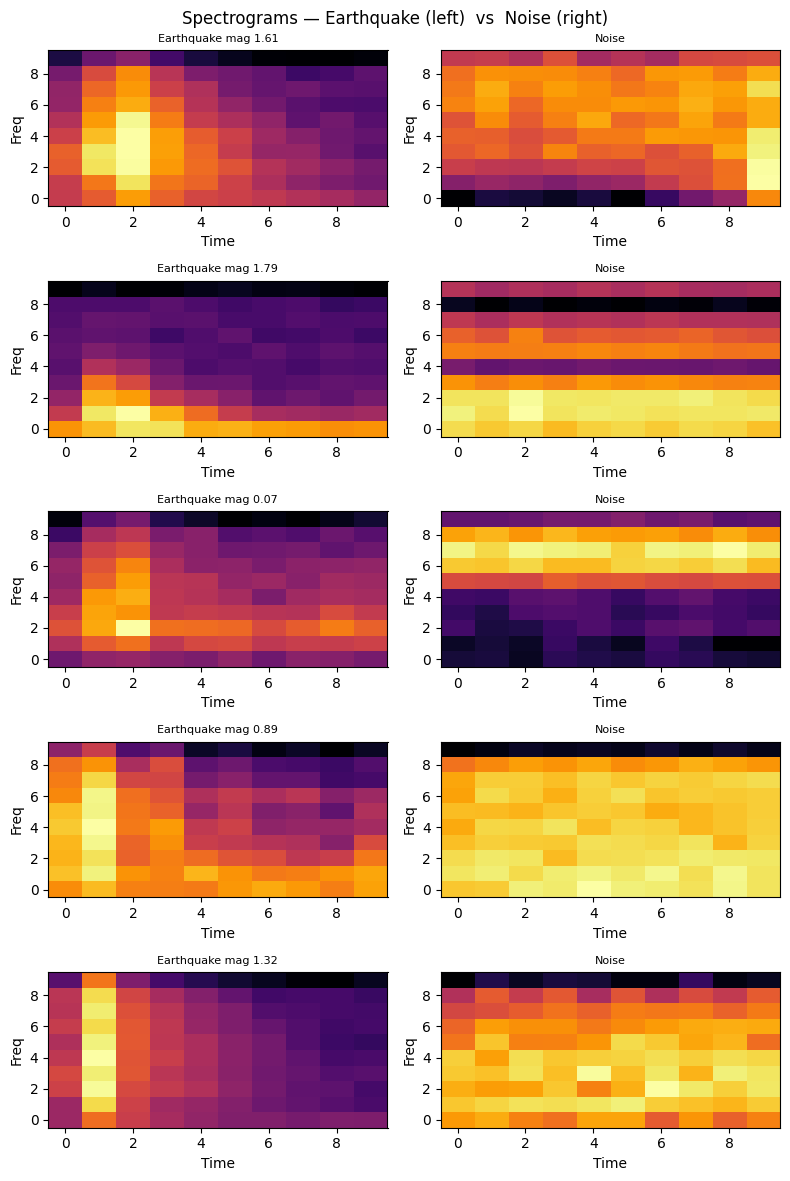

In [6]:
# Spectrograms: 5 earthquakes (left) vs 5 noise (right)
fig, axes = plt.subplots(5, 2, figsize=(8, 12))
fig.suptitle('Spectrograms — Earthquake (left)  vs  Noise (right)', fontsize=12)

for row_i, (eq_i, noi_i) in enumerate(zip(eq_sample, noise_sample)):
    for col_i, (trace_idx, label) in enumerate([(eq_i, 'Earthquake'), (noi_i, 'Noise')]):
        ax  = axes[row_i, col_i]
        row = meta.iloc[trace_idx]
        ax.imshow(X_spec[trace_idx], origin='lower', aspect='auto', cmap='inferno')
        mag = row.get('source_magnitude', '')
        title = label if not pd.notna(mag) or mag == '' else f"{label} mag {mag}"
        ax.set_title(title, fontsize=8)
        ax.set_xlabel('Time')
        ax.set_ylabel('Freq')

plt.tight_layout()
plt.show()